# Mondrian conformal HDF5 demo

This notebook runs Mondrian conformal analysis using saved CNN predictions, labels, and embeddings.

It supports two modes:

- real calibration/test mode, using `pred_cal`, `y_cal`, `emb_cal`, `pred_test`, `y_test`, and `emb_test`
- debug mode, where validation predictions are split into pseudo-calibration and pseudo-test subsets

Debug mode is useful for testing the pipeline, but must not be reported as final conformal performance.

In [19]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import iqr

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name != "cbc_pe" and (PROJECT_ROOT / "cbc_pe").exists():
    PROJECT_ROOT = PROJECT_ROOT / "cbc_pe"

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = Path("/scratch/vserrano/cbc_pe_data")
DATA_RESULTS = DATA_ROOT / "results"

dataset_id = "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
RESULTS_DIR = DATA_RESULTS / dataset_id

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)
print("RESULTS_DIR exists:", RESULTS_DIR.exists())

PROJECT_ROOT: /afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/notebooks
DATA_ROOT: /scratch/vserrano/cbc_pe_data
RESULTS_DIR: /scratch/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n100_000
RESULTS_DIR exists: True


### (Run this only if evaluating the 500k model)

In [25]:
dataset_id_500k = "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"
RESULTS_DIR = DATA_RESULTS / dataset_id_500k

MODEL_ID = "500k_M00_baseline_emb64_seed123"

prediction_files = {
    "500k_M00_baseline_emb64_seed123": RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"
        "_SimpleCNN_Baseline_simple_emb64_mse_MSELoss_seed123"
        "_train_val_cal_test_predictions_embeddings.npz"
    ),
}

prediction_file = prediction_files[MODEL_ID]

assert prediction_file.exists(), prediction_file

print("MODEL_ID:", MODEL_ID)
print("prediction_file:", prediction_file)

data = np.load(prediction_file, allow_pickle=True)
print(data.files)

MODEL_ID: 500k_M00_baseline_emb64_seed123
prediction_file: /scratch/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_Baseline_simple_emb64_mse_MSELoss_seed123_train_val_cal_test_predictions_embeddings.npz
['y_mean', 'y_std', 'label_names', 'checkpoint_file', 'dataset_path', 'split_path', 'label_stats_path', 'model_config', 'pred_train', 'emb_train', 'y_train', 'idx_train', 'pred_val', 'emb_val', 'y_val', 'idx_val', 'pred_cal', 'emb_cal', 'y_cal', 'idx_cal', 'pred_test', 'emb_test', 'y_test', 'idx_test', 'available_splits']


## Select prediction file

For the current 100k architecture-search setup, calibration and test sets are not available. Use debug mode only for pipeline development.

For final reporting, use a prediction file produced from a 70/10/10/10 or similar train/validation/calibration/test split.

In [ ]:
MODEL_ID = "M00_baseline_emb64_seed123"

prediction_files = {
    "M00_baseline_emb64_seed123": RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
    "M00_baseline_emb64_seed124": RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_Baseline_M00_simple_emb64_mse_MSELoss_seed124"
        "_train_val_predictions_embeddings.npz"
    ),
    "M04_pooldeep_emb128_pool4": RESULTS_DIR / (
        "bbh_processed_4s_seobnrv4opt_snr10-25_n100_000"
        "_SimpleCNN_PoolDeep_M04_emb128_pool4_deephead_MSELoss_seed123"
        "_train_val_predictions_embeddings.npz"
    ),
}

prediction_file = prediction_files[MODEL_ID]

assert prediction_file.exists(), prediction_file

print("MODEL_ID:", MODEL_ID)
print("prediction_file:", prediction_file)

data = np.load(prediction_file, allow_pickle=True)
print(data.files)

## Build calibration and test arrays

In [8]:
def load_conformal_arrays(
    data,
    debug_split_val=False,
    debug_cal_fraction=0.5,
    debug_seed=123,
):
    """
    Load arrays needed for Mondrian/conformal.

    Preferred real mode:
        pred_cal, y_cal, emb_cal
        pred_test, y_test, emb_test

    Debug mode:
        If real cal/test are not available, split val into pseudo_cal/pseudo_test.
        This is only for debugging the notebook, not for final reporting.
    """

    files = set(data.files)

    has_real_cal_test = {
        "pred_cal",
        "y_cal",
        "emb_cal",
        "pred_test",
        "y_test",
        "emb_test",
    }.issubset(files)

    if has_real_cal_test:
        print("Using real cal/test arrays.")

        pred_cal = data["pred_cal"]
        y_cal = data["y_cal"]
        emb_cal = data["emb_cal"]

        pred_test = data["pred_test"]
        y_test = data["y_test"]
        emb_test = data["emb_test"]

        idx_cal = data["idx_cal"] if "idx_cal" in files else None
        idx_test = data["idx_test"] if "idx_test" in files else None

        mode = "real_cal_test"

    else:
        if not debug_split_val:
            raise KeyError(
                "No real cal/test arrays found in prediction file. "
                "Expected pred_cal/y_cal/emb_cal and pred_test/y_test/emb_test. "
                "For notebook debugging only, set debug_split_val=True."
            )

        required_val = {"pred_val", "y_val", "emb_val"}

        if not required_val.issubset(files):
            raise KeyError(
                "Cannot create debug split because pred_val/y_val/emb_val are missing."
            )

        print("WARNING: using validation split as pseudo cal/test.")
        print("This is only for debugging. Do not report these results as final.")

        pred_val = data["pred_val"]
        y_val = data["y_val"]
        emb_val = data["emb_val"]

        n_val = pred_val.shape[0]
        rng = np.random.default_rng(debug_seed)
        perm = rng.permutation(n_val)

        n_cal = int(debug_cal_fraction * n_val)

        cal_local = perm[:n_cal]
        test_local = perm[n_cal:]

        pred_cal = pred_val[cal_local]
        y_cal = y_val[cal_local]
        emb_cal = emb_val[cal_local]

        pred_test = pred_val[test_local]
        y_test = y_val[test_local]
        emb_test = emb_val[test_local]

        if "idx_val" in files:
            idx_val = data["idx_val"]
            idx_cal = idx_val[cal_local]
            idx_test = idx_val[test_local]
        else:
            idx_cal = cal_local
            idx_test = test_local

        mode = "debug_val_split"

    y_mean = data["y_mean"]
    y_std = data["y_std"]

    if "label_names" in files:
        label_names = data["label_names"].tolist()
    else:
        label_names = ["chirp_mass", "total_mass", "chi_eff"]

    return {
        "mode": mode,
        "pred_cal": pred_cal,
        "y_cal": y_cal,
        "emb_cal": emb_cal,
        "pred_test": pred_test,
        "y_test": y_test,
        "emb_test": emb_test,
        "idx_cal": idx_cal,
        "idx_test": idx_test,
        "y_mean": y_mean,
        "y_std": y_std,
        "label_names": label_names,
    }

In [9]:
DEBUG_SPLIT_VAL = False  # Debug only. Do not report as final conformal performance.

arrays = load_conformal_arrays(
    data,
    debug_split_val=DEBUG_SPLIT_VAL,
    debug_cal_fraction=0.5,
    debug_seed=123,
)

mode = arrays["mode"]

pred_cal = arrays["pred_cal"]
y_cal = arrays["y_cal"]
emb_cal = arrays["emb_cal"]

pred_test = arrays["pred_test"]
y_test = arrays["y_test"]
emb_test = arrays["emb_test"]

y_mean = arrays["y_mean"]
y_std = arrays["y_std"]
label_names = arrays["label_names"]

print("mode:", mode)
print("pred_cal:", pred_cal.shape)
print("pred_test:", pred_test.shape)
print("labels:", label_names)

if mode != "real_cal_test":
    print("WARNING: running in debug pseudo-cal/test mode. Do not report as final conformal performance.")

Using real cal/test arrays.
mode: real_cal_test
pred_cal: (30000, 3)
pred_test: (30000, 3)
labels: ['chirp_mass', 'total_mass', 'chi_eff']


In [10]:
mode = arrays["mode"]

pred_cal = arrays["pred_cal"]
y_cal = arrays["y_cal"]
emb_cal = arrays["emb_cal"]

pred_test = arrays["pred_test"]
y_test = arrays["y_test"]
emb_test = arrays["emb_test"]

idx_cal = arrays["idx_cal"]
idx_test = arrays["idx_test"]

y_mean = arrays["y_mean"]
y_std = arrays["y_std"]
label_names = arrays["label_names"]

print("mode:", mode)
print("pred_cal:", pred_cal.shape)
print("y_cal:", y_cal.shape)
print("emb_cal:", emb_cal.shape)
print("pred_test:", pred_test.shape)
print("y_test:", y_test.shape)
print("emb_test:", emb_test.shape)
print("y_mean:", y_mean)
print("y_std:", y_std)
print("label_names:", label_names)

mode: real_cal_test
pred_cal: (30000, 3)
y_cal: (30000, 3)
emb_cal: (30000, 64)
pred_test: (30000, 3)
y_test: (30000, 3)
emb_test: (30000, 64)
y_mean: [3.7452621e+01 9.4973969e+01 1.0226952e-03]
y_std: [16.484722   34.650166    0.44085518]
label_names: ['chirp_mass', 'total_mass', 'chi_eff']


In [11]:
#Sanity Checks
assert pred_cal.ndim == 2
assert pred_test.ndim == 2
assert y_cal.ndim == 2
assert y_test.ndim == 2

assert pred_cal.shape == y_cal.shape
assert pred_test.shape == y_test.shape

assert pred_cal.shape[1] == len(label_names)
assert pred_test.shape[1] == len(label_names)

assert emb_cal.ndim == 2
assert emb_test.ndim == 2

assert emb_cal.shape[0] == pred_cal.shape[0]
assert emb_test.shape[0] == pred_test.shape[0]

assert y_mean.shape[0] == len(label_names)
assert y_std.shape[0] == len(label_names)
assert np.all(y_std > 0)

for name, arr in {
    "pred_cal": pred_cal,
    "y_cal": y_cal,
    "pred_test": pred_test,
    "y_test": y_test,
    "emb_cal": emb_cal,
    "emb_test": emb_test,
    "y_mean": y_mean,
    "y_std": y_std,
}.items():
    assert np.all(np.isfinite(arr)), f"{name} contains NaN or inf"

if mode != "real_cal_test":
    print("WARNING: notebook is running in debug mode:", mode)
    print("Do not use these results as final conformal/Mondrian results.")

print("All sanity checks passed.")

All sanity checks passed.


In [12]:
def inverse_standardize(y_std_values, y_mean, y_std):
    return y_std_values * y_std + y_mean


y_cal_phys = inverse_standardize(y_cal, y_mean, y_std)
y_test_phys = inverse_standardize(y_test, y_mean, y_std)

pred_cal_phys = inverse_standardize(pred_cal, y_mean, y_std)
pred_test_phys = inverse_standardize(pred_test, y_mean, y_std)

label_ranges_phys = {
    label: np.max(y_test_phys[:, j]) - np.min(y_test_phys[:, j])
    for j, label in enumerate(label_names)
}

label_ranges_phys

{'chirp_mass': np.float32(73.19801),
 'total_mass': np.float32(168.1535),
 'chi_eff': np.float32(1.9890721)}

## Start Mondrian

In [13]:
confidence_level = 0.90

if mode == "real_cal_test":
    n_bins_grid = [4, 6, 8, 12, 16, 24, 32, 48]
else:
    n_bins_grid = [4, 6, 8, 12, 16, 24]

taxonomy_modes = ["prediction", "difficulty"]
interval_modes = ["symmetric", "asymmetric"]

n_neighbors = 5
min_samples_per_bin = 20 if mode == "real_cal_test" else 10

rows = []
all_results = {}

In [22]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe")  # ajusta si tu repo está en otra ruta

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

from src.conformal.pipeline import run_mondrian_regression

/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe


In [23]:

for taxonomy_mode in taxonomy_modes:
    for interval_mode in interval_modes:
        for n_bins in n_bins_grid:

            kwargs = dict(
                pred_cal=pred_cal,
                pred_test=pred_test,
                y_cal=y_cal,
                y_test=y_test,
                n_bins=n_bins,
                confidence_level=confidence_level,
                apply_jitter=True,
                interval_mode=interval_mode,
                taxonomy_mode=taxonomy_mode,
                min_samples_per_bin=min_samples_per_bin,
                tolerance_sigmas=(1, 2, 3),
            )

            if taxonomy_mode == "difficulty":
                kwargs.update(
                    cal_embedding=emb_cal,
                    target_embedding=emb_test,
                    n_neighbors=n_neighbors,
                )

            result = run_mondrian_regression(**kwargs)
            all_results[(taxonomy_mode, interval_mode, n_bins)] = result

            metrics = result.metrics

            widths_std = result.upper - result.lower
            widths_phys = widths_std * y_std

            for j, label in enumerate(label_names):
                n_bad_bins_p005 = int(
                    np.nansum(metrics["bin_undercoverage_pvalue"][:, j] < 0.05)
                )

                row = {
                    "mode": mode,
                    "taxonomy_mode": taxonomy_mode,
                    "interval_mode": interval_mode,
                    "n_bins": n_bins,
                    "label": label,
                    "label_index": j,

                    "n_samples": int(metrics["n_samples_per_label"][j]),
                    "covered_count": int(metrics["covered_count_global"][j]),

                    "global_coverage": metrics["global_coverage"][j],
                    "miscoverage": metrics["miscoverage"][j],
                    "global_coverage_gap": metrics["global_coverage_gap"][j],
                    "global_undercoverage_pvalue": metrics["global_undercoverage_pvalue"][j],

                    "global_mean_width_std": metrics["global_mean_width"][j],
                    "global_median_width_std": metrics["global_median_width"][j],

                    "global_mean_width_phys": np.mean(widths_phys[:, j]),
                    "global_median_width_phys": np.median(widths_phys[:, j]),
                    "global_iqr_width_phys": iqr(widths_phys[:, j]),

                    "normalized_median_width_range": (
                        np.median(widths_phys[:, j]) / label_ranges_phys[label]
                    ),

                    "min_coverage_per_bin": metrics["min_coverage_per_label"][j],
                    "max_undercoverage_gap": metrics["max_undercoverage_gap"][j],

                    "min_count_per_bin": int(np.nanmin(metrics["counts_per_bin"][:, j])),
                    "max_count_per_bin": int(np.nanmax(metrics["counts_per_bin"][:, j])),

                    "n_bad_bins_p005": n_bad_bins_p005,
                    "bad_bin_fraction": n_bad_bins_p005 / n_bins,

                    "global_lower_miss_rate": metrics["global_lower_miss_rate"][j],
                    "global_upper_miss_rate": metrics["global_upper_miss_rate"][j],
                    "global_tail_miss_imbalance": metrics["global_tail_miss_imbalance"][j],
                }

                global_tol = metrics["global_tolerance_normal"]

                for k in [1, 2, 3]:
                    low = global_tol[f"{k}sigma_low"][j]
                    high = global_tol[f"{k}sigma_high"][j]
                    width = global_tol[f"{k}sigma_width"][j]

                    row[f"global_tol_{k}sigma_low"] = low
                    row[f"global_tol_{k}sigma_high"] = high
                    row[f"global_tol_{k}sigma_width"] = width
                    row[f"global_within_{k}sigma"] = bool(low <= metrics["global_coverage"][j] <= high)

                rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df

,mode,taxonomy_mode,interval_mode,n_bins,label,label_index,n_samples,covered_count,global_coverage,miscoverage,global_coverage_gap,global_undercoverage_pvalue,global_mean_width_std,global_median_width_std,global_mean_width_phys,global_median_width_phys,global_iqr_width_phys,normalized_median_width_range,min_coverage_per_bin,max_undercoverage_gap,min_count_per_bin,max_count_per_bin,n_bad_bins_p005,bad_bin_fraction,global_lower_miss_rate,global_upper_miss_rate,global_tail_miss_imbalance,global_tol_1sigma_low,global_tol_1sigma_high,global_tol_1sigma_width,global_within_1sigma,global_tol_2sigma_low,global_tol_2sigma_high,global_tol_2sigma_width,global_within_2sigma,global_tol_3sigma_low,global_tol_3sigma_high,global_tol_3sigma_width,global_within_3sigma
0,real_cal_test,prediction,symmetric,4,chirp_mass,0,30000,27072,0.902400,0.097600,0.002400,0.918903,1.029727,0.971662,16.974760,16.017577,11.650711,0.218825,0.899128,0.000872,7429,7572,0,0.000000,0.049967,0.047633,0.002333,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
1,real_cal_test,prediction,symmetric,4,total_mass,1,30000,27098,0.903267,0.096733,0.003267,0.971441,0.938866,0.851267,32.531845,29.496558,4.612983,0.175414,0.901239,0.000000,7420,7584,0,0.000000,0.037067,0.059667,0.022600,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
2,real_cal_test,prediction,symmetric,4,chi_eff,2,30000,26924,0.897467,0.102533,0.002533,0.073503,1.497747,1.416719,0.660289,0.624568,0.205515,0.314000,0.892031,0.007969,7391,7613,1,0.250000,0.049067,0.053467,0.004400,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
3,real_cal_test,prediction,symmetric,6,chirp_mass,0,30000,27079,0.902633,0.097367,0.002633,0.937420,1.036094,1.071030,17.079718,17.655627,8.419937,0.241204,0.895912,0.004088,4895,5076,0,0.000000,0.051100,0.046267,0.004833,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
4,real_cal_test,prediction,symmetric,6,total_mass,1,30000,27114,0.903800,0.096200,0.003800,0.986573,0.939620,0.874892,32.557984,30.315136,7.805594,0.180283,0.898135,0.001865,4927,5095,0,0.000000,0.036567,0.059633,0.023067,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,False,0.894804,0.905196,0.005196,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,real_cal_test,difficulty,asymmetric,32,total_mass,1,30000,27094,0.903133,0.096867,0.003133,0.965975,0.919742,0.884964,31.869228,30.664153,12.719967,0.182358,0.870932,0.029068,869,1021,1,0.031250,0.050267,0.046600,0.003667,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
92,real_cal_test,difficulty,asymmetric,32,chi_eff,2,30000,26986,0.899533,0.100467,0.000467,0.396584,1.465593,1.380875,0.646114,0.608766,0.161789,0.306055,0.859956,0.040044,852,1023,3,0.093750,0.050433,0.050033,0.000400,0.898268,0.901732,0.001732,True,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
93,real_cal_test,difficulty,asymmetric,48,chirp_mass,0,30000,26934,0.897800,0.102200,0.002200,0.104004,0.989880,0.957913,16.317893,15.790936,8.923191,0.215729,0.856287,0.043713,547,714,7,0.145833,0.051600,0.050600,0.001000,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True
94,real_cal_test,difficulty,asymmetric,48,total_mass,1,30000,27067,0.902233,0.097767,0.002233,0.903342,0.917244,0.883457,31.782653,30.611934,12.438681,0.182048,0.869191,0.030809,548,707,6,0.125000,0.051300,0.046467,0.004833,0.898268,0.901732,0.001732,False,0.896536,0.903464,0.003464,True,0.894804,0.905196,0.005196,True


## Save the results

In [26]:
mondrian_results_dir = RESULTS_DIR / "mondrian"
mondrian_results_dir.mkdir(parents=True, exist_ok=True)

prediction_stem = prediction_file.stem

summary_path = mondrian_results_dir / f"{prediction_stem}_mondrian_summary_{mode}.csv"

summary_df.to_csv(summary_path, index=False)

print("Saved:", summary_path)

Saved: /scratch/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/mondrian/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_Baseline_simple_emb64_mse_MSELoss_seed123_train_val_cal_test_predictions_embeddings_mondrian_summary_real_cal_test.csv


## Ranking Configurations

### Filtering the configurations

In [27]:
# 1. First we remove the configs that does not pass the pre-cut:
# within 2 sigma nominal CL, min counts per bin is 20 and fraction of bins with statisticall p<5% is less or equal 10 %
if mode == "real_cal_test":
    min_count_threshold = 20
    max_bad_bin_fraction = 0.10
else:
    min_count_threshold = 20
    max_bad_bin_fraction = 0.10

candidate_df = summary_df[
    (summary_df["global_within_2sigma"]) &
    (summary_df["min_count_per_bin"] >= min_count_threshold) &
    (summary_df["bad_bin_fraction"] <= max_bad_bin_fraction)
].copy()

ranking_df = candidate_df.sort_values(
    ["label", "global_median_width_std", "max_undercoverage_gap"],
    ascending=[True, True, True],
)

ranking_df[
    [
        "label",
        "taxonomy_mode",
        "interval_mode",
        "n_bins",
        "global_coverage",
        "global_within_1sigma",
        "global_within_2sigma",
        "global_undercoverage_pvalue",
        "min_coverage_per_bin",
        "max_undercoverage_gap",
        "n_bad_bins_p005",
        "bad_bin_fraction",
        "global_median_width_std",
        "global_median_width_phys",
        "normalized_median_width_range",
        "global_iqr_width_phys",
        "global_lower_miss_rate",
        "global_upper_miss_rate",
        "global_tail_miss_imbalance",
        "min_count_per_bin",
    ]
]

print("Mode:", mode)
print("Summary configs:", summary_df.groupby("label").size())
print("Passed configs:", candidate_df.groupby("label").size())


Mode: real_cal_test
Summary configs: label
chi_eff       32
chirp_mass    32
total_mass    32
dtype: int64
Passed configs: label
chi_eff        3
chirp_mass    19
total_mass    25
dtype: int64


### We see the best k configs per label

In [28]:
# best k configs for each label
top_k = 5

top_by_label = (
    ranking_df
    .groupby("label", group_keys=False)
    .head(top_k)
)

# show only the following columns
top_by_label[
    [
        "label",
        "taxonomy_mode",
        "interval_mode",
        "n_bins",
        "global_coverage",
        "global_median_width_std",
        "global_median_width_phys",
        "bad_bin_fraction",
        "max_undercoverage_gap",
        "global_tail_miss_imbalance",
    ]
]

,label,taxonomy_mode,interval_mode,n_bins,global_coverage,global_median_width_std,global_median_width_phys,bad_bin_fraction,max_undercoverage_gap,global_tail_miss_imbalance
68,chi_eff,difficulty,symmetric,32,0.899833,1.378087,0.607537,0.093750,0.049254,0.000167
71,chi_eff,difficulty,symmetric,48,0.900567,1.379248,0.608049,0.083333,0.056800,0.000900
92,chi_eff,difficulty,asymmetric,32,0.899533,1.380875,0.608766,0.093750,0.040044,0.000400
48,chirp_mass,difficulty,symmetric,4,0.900700,0.844578,13.922626,0.000000,0.003965,0.003967
72,chirp_mass,difficulty,asymmetric,4,0.901267,0.845172,13.932419,0.000000,0.004223,0.001600
78,chirp_mass,difficulty,asymmetric,8,0.898967,0.892470,14.712123,0.000000,0.007451,0.000433
57,chirp_mass,difficulty,symmetric,12,0.898900,0.914581,15.076621,0.000000,0.010084,0.002567
87,chirp_mass,difficulty,asymmetric,24,0.898800,0.920793,15.179020,0.083333,0.019273,0.000333
49,total_mass,difficulty,symmetric,4,0.901467,0.799856,27.715133,0.000000,0.002259,0.027200
73,total_mass,difficulty,asymmetric,4,0.902400,0.808331,28.008818,0.000000,0.000000,0.000533


## Checking a configuration

In [29]:
def inspect_configuration(
    all_results,
    key,
    label_idx,
    label_names,
):
    result = all_results[key]
    metrics = result.metrics
    label = label_names[label_idx]

    print("Configuration:", key)
    print("Label:", label)

    print("\nCounts per bin:")
    print(metrics["counts_per_bin"][:, label_idx])

    print("\nCoverage per bin:")
    print(np.round(metrics["coverage_per_bin"][:, label_idx], 3))

    print("\nCovered count per bin:")
    print(metrics["covered_count_per_bin"][:, label_idx])

    print("\nBin undercoverage p-values:")
    print(np.round(metrics["bin_undercoverage_pvalue"][:, label_idx], 4))

    print("\nLower miss rate per bin:")
    print(np.round(metrics["lower_miss_rate_per_bin"][:, label_idx], 3))

    print("\nUpper miss rate per bin:")
    print(np.round(metrics["upper_miss_rate_per_bin"][:, label_idx], 3))

    print("\nInterval offsets per bin:")
    print(np.round(result.intervals[label_idx], 4))

    print("\nCalibrator bin counts:")
    print(result.calibrator.bin_counts_[label_idx])

    if hasattr(result.calibrator, "quantile_indices_"):
        print("\nQuantile indices:")
        print(result.calibrator.quantile_indices_[label_idx])

In [30]:
key = ("difficulty", "asymmetric", 12)
inspect_configuration(
    all_results=all_results,
    key=key,
    label_idx=0,
    label_names=label_names,
)

Configuration: ('difficulty', 'asymmetric', 12)
Label: chirp_mass

Counts per bin:
[2538 2631 2574 2335 2433 2530 2489 2550 2460 2460 2512 2488]

Coverage per bin:
[0.892 0.886 0.892 0.901 0.898 0.901 0.89  0.894 0.908 0.898 0.907 0.899]

Covered count per bin:
[2265 2331 2297 2103 2186 2279 2214 2280 2233 2209 2278 2236]

Bin undercoverage p-values:
[0.1088 0.01   0.1056 0.5513 0.4111 0.5624 0.0451 0.169  0.9061 0.3781
 0.8812 0.425 ]

Lower miss rate per bin:
[0.051 0.049 0.056 0.051 0.045 0.052 0.057 0.05  0.048 0.054 0.04  0.06 ]

Upper miss rate per bin:
[0.056 0.065 0.052 0.049 0.056 0.047 0.054 0.056 0.044 0.048 0.053 0.041]

Interval offsets per bin:
[[-0.2177  0.1853]
 [-0.2733  0.2553]
 [-0.322   0.3392]
 [-0.3683  0.3933]
 [-0.4287  0.4318]
 [-0.4348  0.4763]
 [-0.4742  0.514 ]
 [-0.5429  0.5459]
 [-0.6013  0.6028]
 [-0.6122  0.6479]
 [-0.7352  0.69  ]
 [-0.861   0.969 ]]

Calibrator bin counts:
[2500 2500 2500 2500 2500 2500 2500 2500 2500 2500 2500 2500]

Quantile indices:

## Plots

In [32]:
plot_labels = {
    "chirp_mass": r"$\mathcal{M}$",
    "total_mass": r"$M_{\mathrm{tot}}$",
    "chi_eff": r"$\chi_{\mathrm{eff}}$",
}

plot_colors = {
    "symmetric": "teal",
    "asymmetric": "dodgerblue",
}


def plot_global_coverage_vs_bins(
    summary_df,
    label,
    taxonomy_modes,
    interval_modes,
    confidence_level,
    plot_labels,
    plot_colors=None,
):
    df_label = summary_df[summary_df["label"] == label]

    fig, axes = plt.subplots(
        1,
        len(taxonomy_modes),
        figsize=(14, 5),
        sharey=True,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes)

    for ax, taxonomy_mode in zip(axes, taxonomy_modes):
        df_tax = df_label[df_label["taxonomy_mode"] == taxonomy_mode]

        if df_tax.empty:
            ax.set_title(f"{taxonomy_mode} (no data)")
            continue

        # Global tolerance is constant for this label.
        low_1 = df_tax["global_tol_1sigma_low"].iloc[0]
        high_1 = df_tax["global_tol_1sigma_high"].iloc[0]
        low_2 = df_tax["global_tol_2sigma_low"].iloc[0]
        high_2 = df_tax["global_tol_2sigma_high"].iloc[0]
        low_3 = df_tax["global_tol_3sigma_low"].iloc[0]
        high_3 = df_tax["global_tol_3sigma_high"].iloc[0]

        ax.axhspan(low_1, high_1, alpha=0.20, label=r"$1\sigma$")
        ax.axhspan(low_2, high_2, alpha=0.15, label=r"$2\sigma$")
        ax.axhspan(low_3, high_3, alpha=0.10, label=r"$3\sigma$")

        ax.axhline(
            confidence_level,
            color="black",
            linestyle="--",
            linewidth=1,
            label=rf"C.L. = {int(confidence_level * 100)}%",
        )

        for interval_mode in interval_modes:
            df_mode = (
                df_tax[df_tax["interval_mode"] == interval_mode]
                .sort_values("n_bins")
            )

            color = None if plot_colors is None else plot_colors.get(interval_mode)

            ax.plot(
                df_mode["n_bins"],
                df_mode["global_coverage"],
                marker="o",
                label=interval_mode,
                color=color,
            )

        ax.set_xticks(sorted(df_tax["n_bins"].unique()))
        ax.set_xlabel(r"$n_{\mathrm{bins}}$", fontsize=13)
        ax.set_title(taxonomy_mode)
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("Global coverage", fontsize=13)

    fig.suptitle(f"Coverage vs bins ({plot_labels[label]})", fontsize=16)

    handles, labels_legend = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels_legend,
        loc="upper left",
        bbox_to_anchor=(0.82, 1.08),
        ncol=2,
    )

    plt.show()

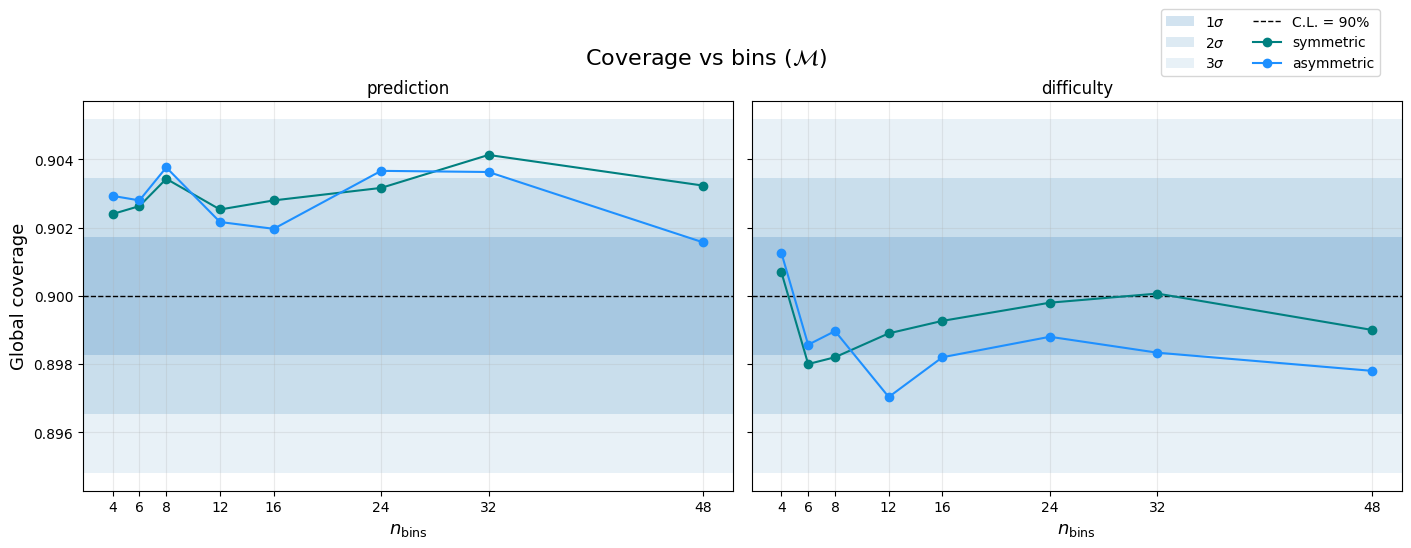

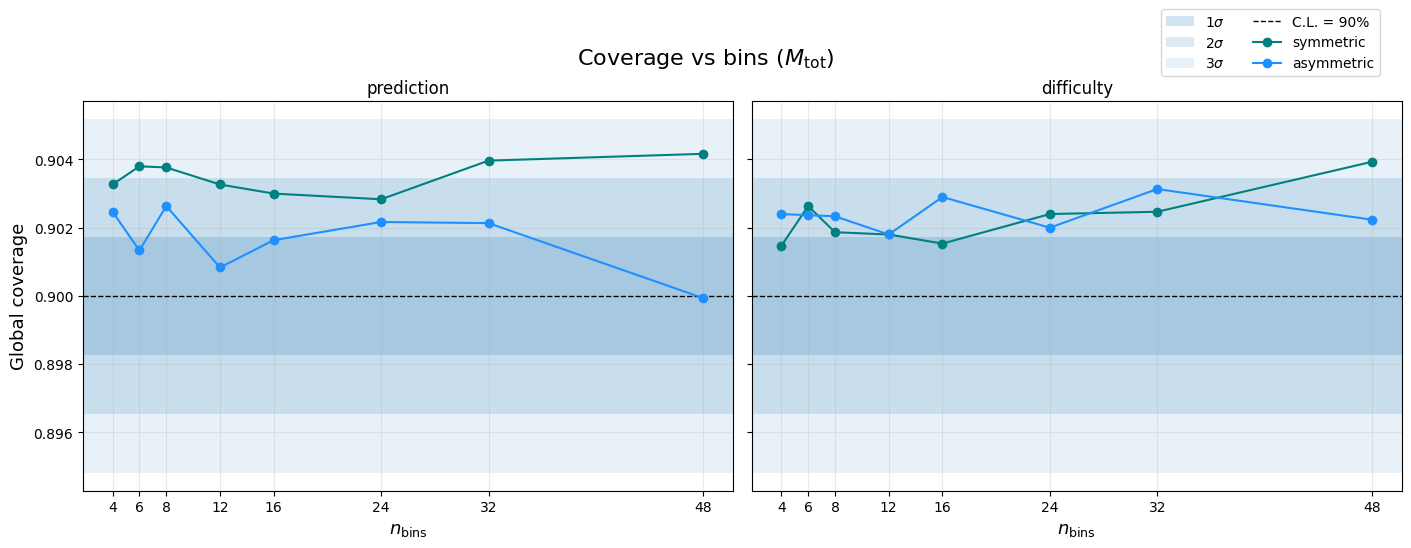

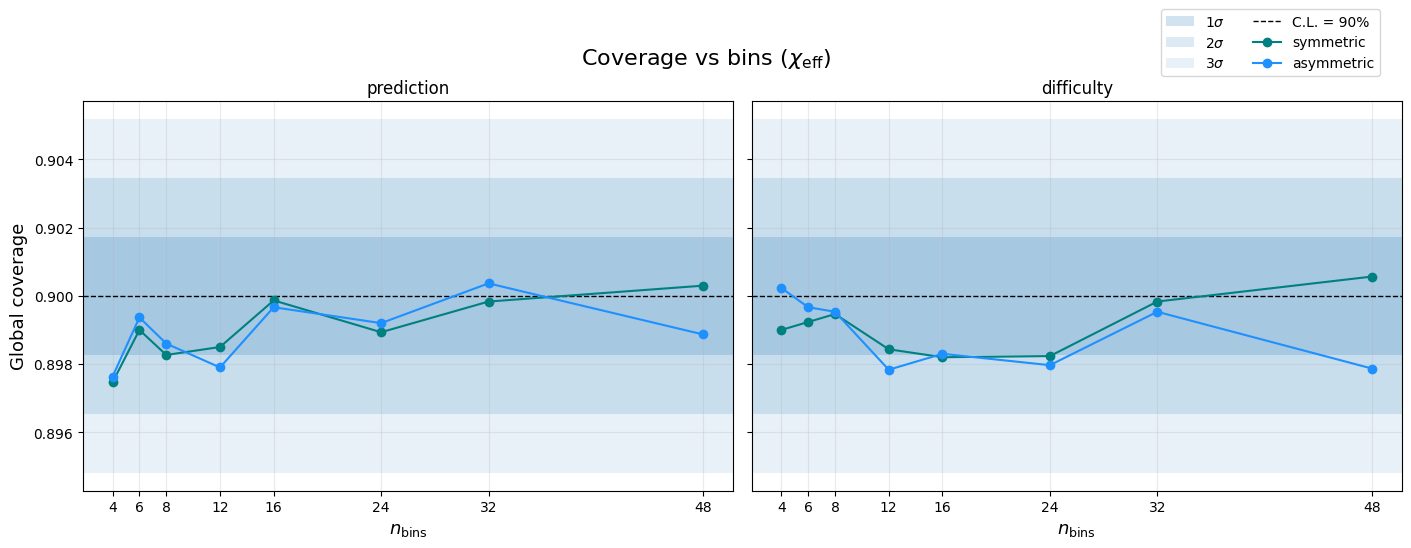

In [33]:
for label in label_names:
    plot_global_coverage_vs_bins(
        summary_df=summary_df,
        label=label,
        taxonomy_modes=taxonomy_modes,
        interval_modes=interval_modes,
        confidence_level=confidence_level,
        plot_labels=plot_labels,
        plot_colors=plot_colors,
    )

In [34]:
def plot_width_vs_bins(
    summary_df,
    label,
    taxonomy_modes,
    interval_modes,
    plot_labels,
    width_column="global_median_width_std",
    plot_colors=None,
):
    df_label = summary_df[summary_df["label"] == label]

    fig, axes = plt.subplots(
        1,
        len(taxonomy_modes),
        figsize=(14, 5),
        sharey=True,
        constrained_layout=True,
    )

    axes = np.atleast_1d(axes)

    for ax, taxonomy_mode in zip(axes, taxonomy_modes):
        df_tax = df_label[df_label["taxonomy_mode"] == taxonomy_mode]

        for interval_mode in interval_modes:
            df_mode = (
                df_tax[df_tax["interval_mode"] == interval_mode]
                .sort_values("n_bins")
            )

            color = None if plot_colors is None else plot_colors.get(interval_mode)

            ax.plot(
                df_mode["n_bins"],
                df_mode[width_column],
                marker="o",
                label=interval_mode,
                color=color,
            )

        ax.set_title(taxonomy_mode)
        ax.set_xlabel(r"$n_{\mathrm{bins}}$", fontsize=13)
        ax.set_xticks(sorted(df_tax["n_bins"].unique()))
        ax.grid(alpha=0.25)

    axes[0].set_ylabel(width_column, fontsize=13)
    fig.suptitle(f"Interval width vs bins ({plot_labels[label]})", fontsize=16)

    handles, labels_legend = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels_legend,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.08),
        ncol=2,
    )

    plt.show()

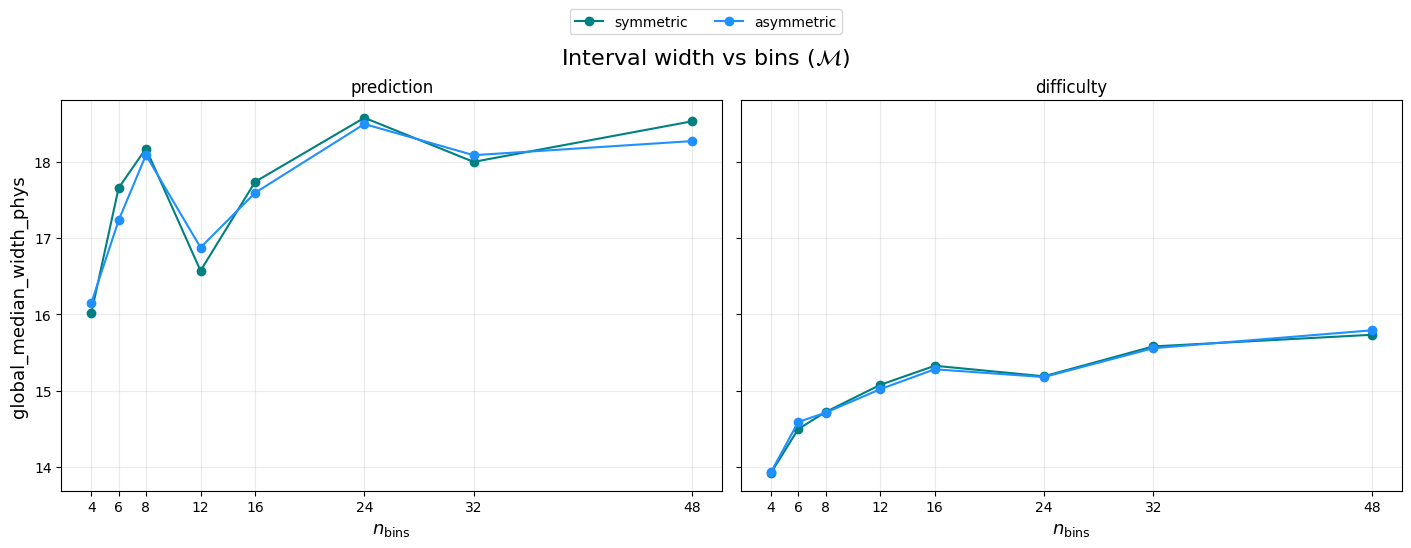

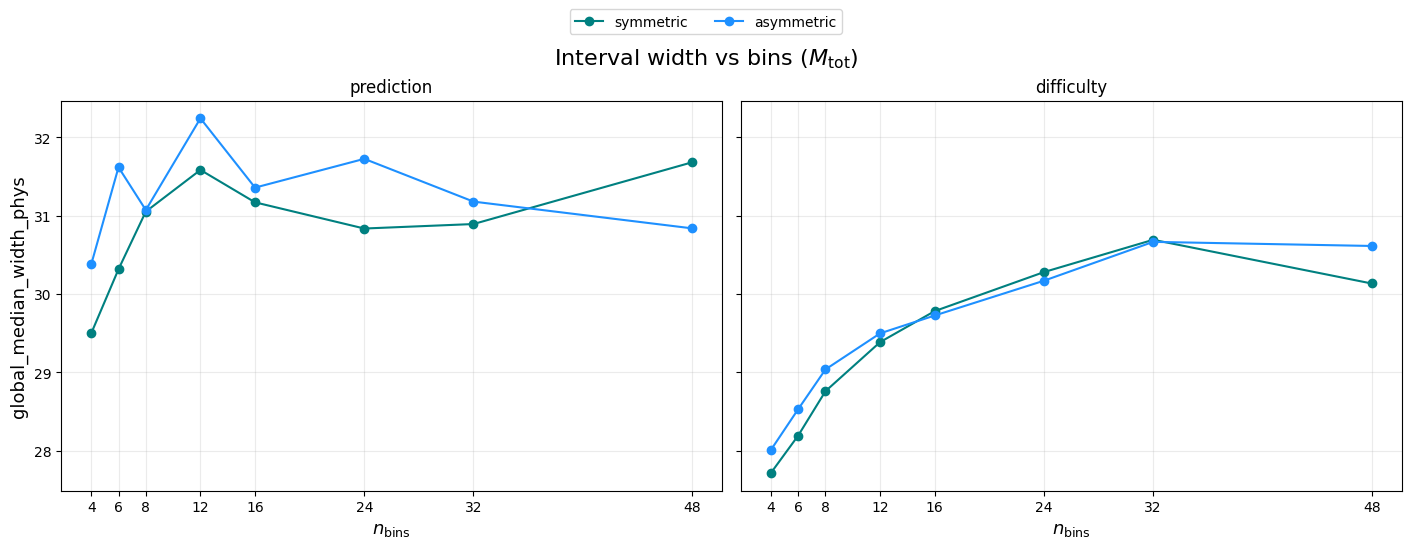

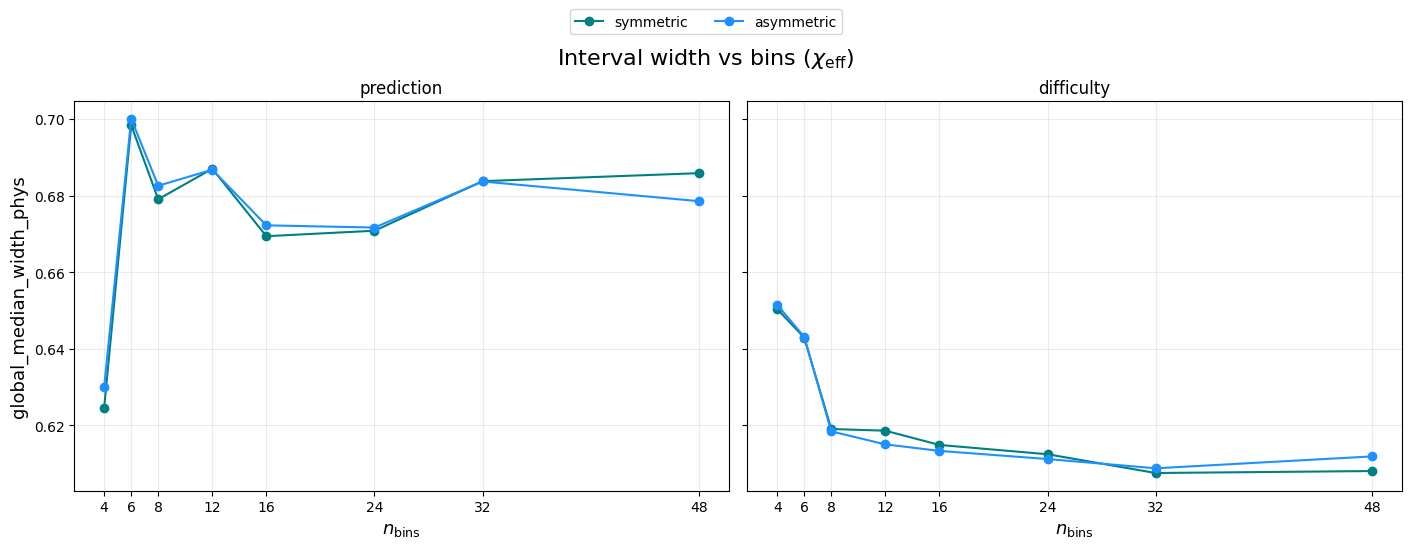

In [35]:
for label in label_names:
    plot_width_vs_bins(
        summary_df=summary_df,
        label=label,
        taxonomy_modes=taxonomy_modes,
        interval_modes=interval_modes,
        plot_labels=plot_labels,
        width_column="global_median_width_phys",
        plot_colors=plot_colors,
    )

In [36]:
def plot_coverage_width_tradeoff(
    summary_df,
    label,
    taxonomy_modes,
    interval_modes,
    confidence_level,
    plot_labels,
    width_column="global_median_width_std",
):
    df_label = summary_df[summary_df["label"] == label]

    scatter_color = {

    }

    plt.figure(figsize=(16, 10))

    for taxonomy_mode in taxonomy_modes:
        for interval_mode in interval_modes:
            df_mode = df_label[
                (df_label["taxonomy_mode"] == taxonomy_mode) &
                (df_label["interval_mode"] == interval_mode)
            ]

            plt.scatter(
                df_mode[width_column],
                df_mode["global_coverage"],
                s=350,
                label=f"{taxonomy_mode}-{interval_mode}",
            )

            for _, row in df_mode.iterrows():
                plt.text(
                    row[width_column],
                    row["global_coverage"],
                    str(row["n_bins"]),
                    fontsize=14,
                    ha="center",
                    va="center",
                    color="white",
                )

    plt.axhline(confidence_level, color="black", linestyle="--", linewidth=1)
    plt.xlabel(width_column)
    plt.ylabel("Global coverage")
    plt.title(f"Coverage-efficiency tradeoff ({plot_labels[label]})", fontsize=18)
    plt.grid(alpha=0.25)
    plt.legend(fontsize=14)
    plt.show()

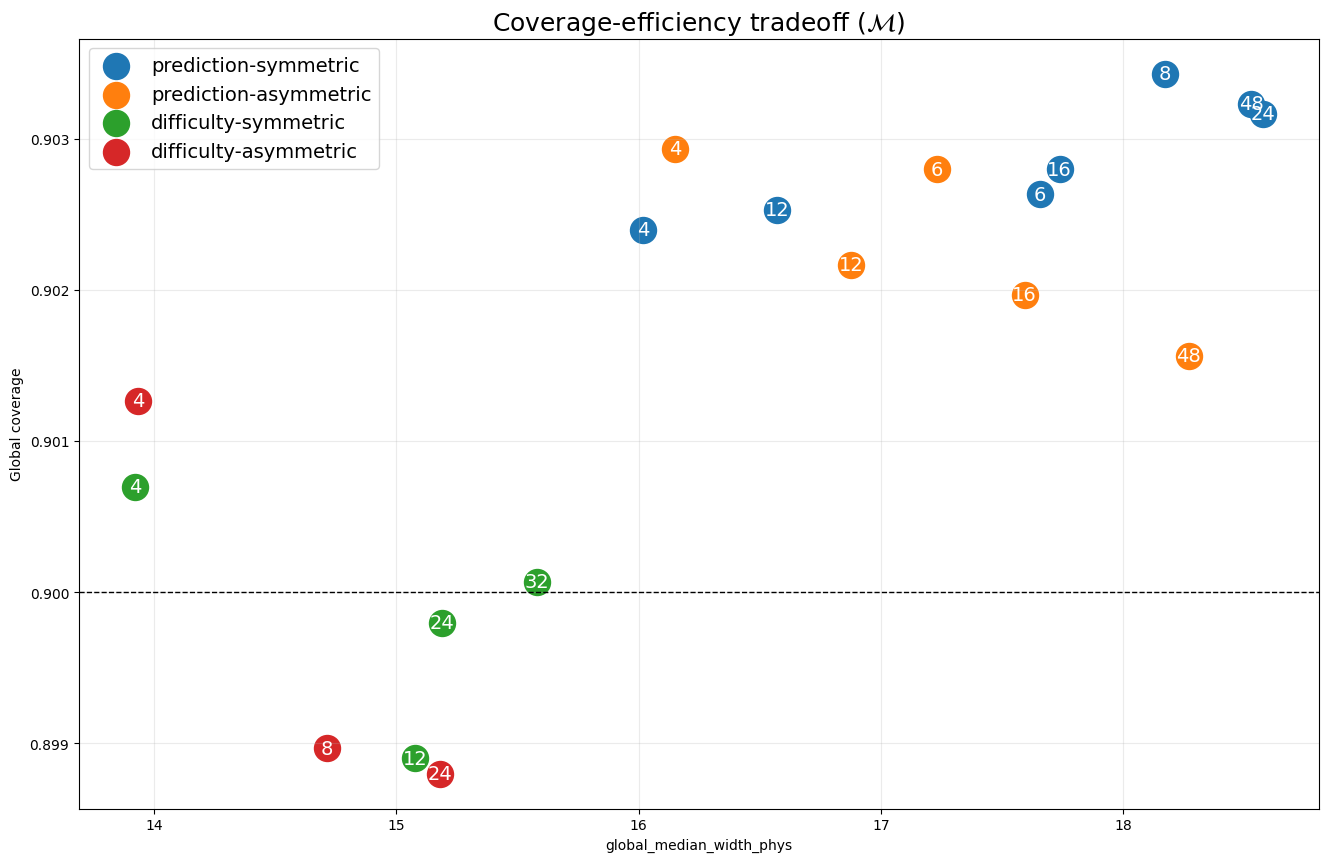

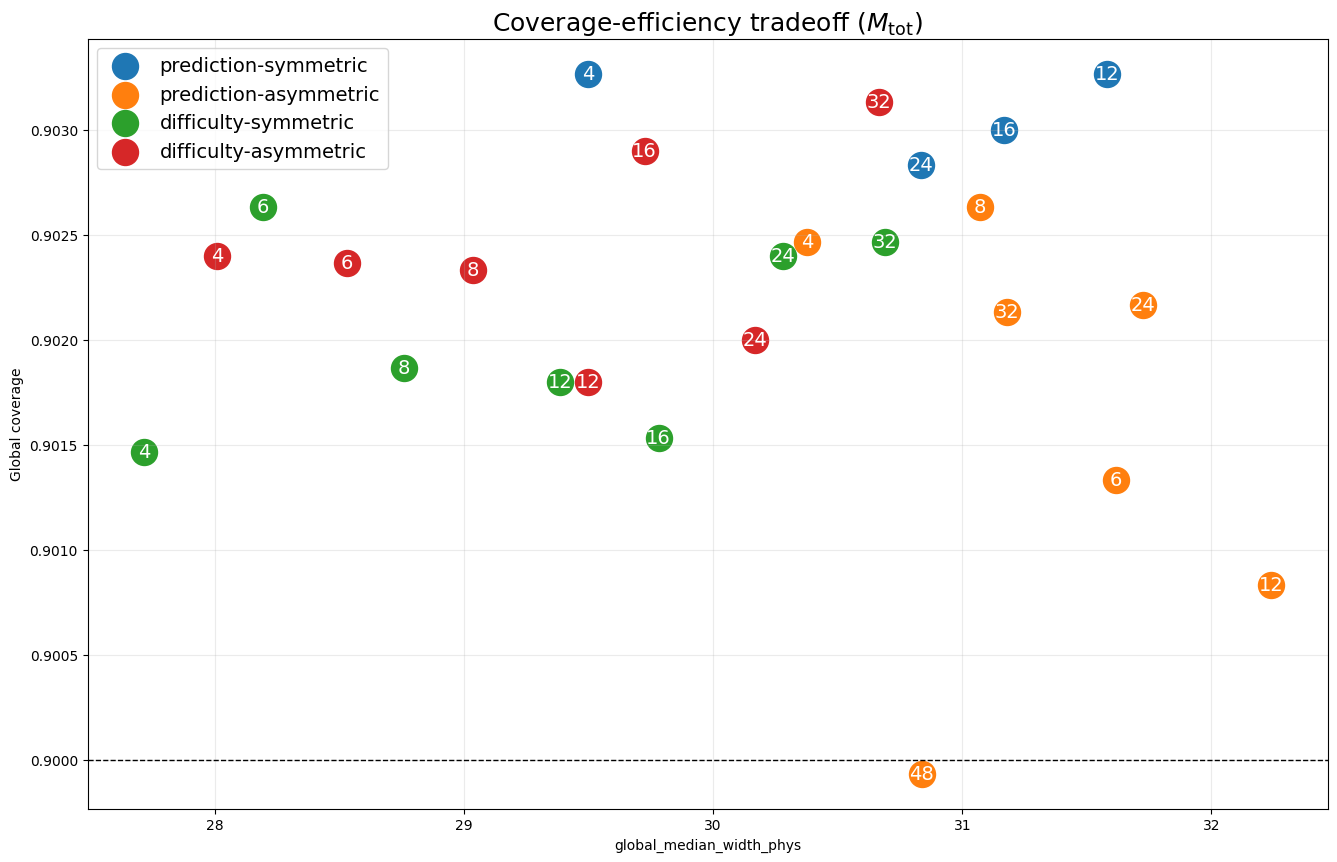

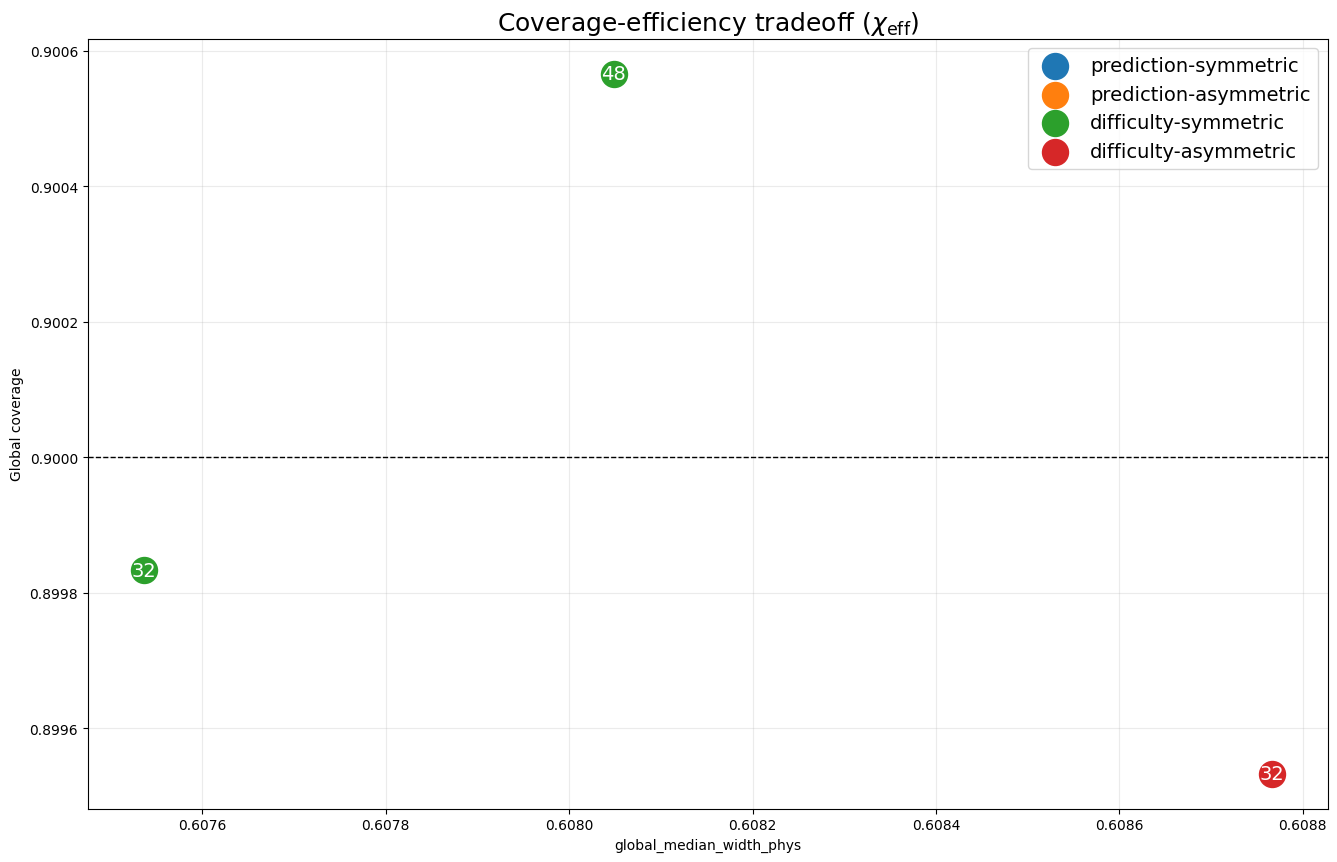

In [37]:
for label in label_names:
    plot_coverage_width_tradeoff(
        summary_df=candidate_df,
        label=label,
        taxonomy_modes=taxonomy_modes,
        interval_modes=interval_modes,
        confidence_level=confidence_level,
        plot_labels=plot_labels,
        width_column="global_median_width_phys",
    )

In [38]:
import numpy as np
import matplotlib.pyplot as plt


def plot_coverage_and_width_per_bin(
    all_results,
    key,
    label_idx,
    label_names,
    plot_labels,
    confidence_level,
    width_stat="mean",          # "mean" or "median"
    width_space="std",          # "std" or "phys"
    y_std=None,                 # required if width_space="phys"
    coverage_ylim=(0.85, 0.95),
    width_ylim=None,
    annotate_counts=True,
):
    result = all_results[key]
    metrics = result.metrics

    label = label_names[label_idx]
    title_label = plot_labels[label] if label in plot_labels else label

    coverage_per_bin = metrics["coverage_per_bin"][:, label_idx]
    counts_per_bin = metrics["counts_per_bin"][:, label_idx]
    bin_tol = metrics["bin_tolerance_normal"]

    n_bins = len(coverage_per_bin)
    x = np.arange(n_bins)

    # ------------------------------------------------------------------
    # Width per bin
    # ------------------------------------------------------------------
    width_key = f"{width_stat}_width_per_bin"

    if width_key in metrics:
        width_per_bin = metrics[width_key][:, label_idx].astype(float)
    else:
        # Fallback: compute from test intervals
        bin_indices_test = result.bin_indices_test
        widths = result.upper - result.lower  # (n_test, n_labels)

        width_per_bin = np.full(n_bins, np.nan)

        for b in range(n_bins):
            mask = bin_indices_test[:, label_idx] == b

            if np.sum(mask) == 0:
                continue

            if width_stat == "mean":
                width_per_bin[b] = np.mean(widths[mask, label_idx])
            elif width_stat == "median":
                width_per_bin[b] = np.median(widths[mask, label_idx])
            else:
                raise ValueError("width_stat must be 'mean' or 'median'.")

    if width_stat not in ["mean", "median"]:
        raise ValueError("width_stat must be 'mean' or 'median'.")

    if width_space == "phys":
        if y_std is None:
            raise ValueError("y_std must be provided when width_space='phys'.")

        width_per_bin = width_per_bin * y_std[label_idx]
        width_ylabel = f"{width_stat.capitalize()} interval width [{label}]"

    elif width_space == "std":
        width_ylabel = f"{width_stat.capitalize()} interval width [standardized]"

    else:
        raise ValueError("width_space must be 'std' or 'phys'.")

    # ------------------------------------------------------------------
    # Coverage bands
    # ------------------------------------------------------------------
    low_1 = bin_tol["1sigma_low"][:, label_idx]
    low_2 = bin_tol["2sigma_low"][:, label_idx]
    low_3 = bin_tol["3sigma_low"][:, label_idx]

    high_1 = bin_tol["1sigma_high"][:, label_idx]
    high_2 = bin_tol["2sigma_high"][:, label_idx]
    high_3 = bin_tol["3sigma_high"][:, label_idx]

    # ------------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------------
    fig, ax1 = plt.subplots(figsize=(9.5, 5.2))

    band_color = "tab:red"

    ax1.fill_between(
        x, low_3, high_3,
        color=band_color,
        alpha=0.10,
        label=r"Nominal 3$\sigma$",
        zorder=1,
    )

    ax1.fill_between(
        x, low_2, high_2,
        color=band_color,
        alpha=0.15,
        label=r"Nominal 2$\sigma$",
        zorder=2,
    )

    ax1.fill_between(
        x, low_1, high_1,
        color=band_color,
        alpha=0.20,
        label=r"Nominal 1$\sigma$",
        zorder=3,
    )

    ax1.plot(
        x,
        coverage_per_bin,
        marker="o",
        color="maroon",
        label="Empirical coverage",
        zorder=4,
    )

    ax1.axhline(
        confidence_level,
        linestyle="--",
        alpha=0.6,
        linewidth=1.0,
        color="black",
        label=rf"C.L. = {confidence_level}",
    )

    if annotate_counts:
        for i, n in enumerate(counts_per_bin):
            if np.isfinite(coverage_per_bin[i]):
                ax1.text(
                    i,
                    coverage_per_bin[i] + 0.005,
                    str(int(n)),
                    ha="center",
                    fontsize=9,
                    color="black",
                )

    ax1.set_xlabel("Bin index")
    ax1.set_ylabel("Coverage")
    ax1.set_ylim(*coverage_ylim)
    ax1.grid(alpha=0.25)

    # ------------------------------------------------------------------
    # Right axis: interval width
    # ------------------------------------------------------------------
    ax2 = ax1.twinx()

    ax2.plot(
        x,
        width_per_bin,
        marker="s",
        linestyle="-",
        color="tab:blue",
        label=f"{width_stat} interval width",
        zorder=5,
    )

    ax2.set_ylabel(width_ylabel)

    if width_ylim is not None:
        ax2.set_ylim(*width_ylim)

    ax1.set_title(
        f"Coverage and interval width per bin | {title_label} | {key}"
    )

    # Combine legends
    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()

    ax1.legend(
        handles1 + handles2,
        labels1 + labels2,
        ncols=2,
        loc="lower right",
    )

    plt.tight_layout()
    plt.show()

    return width_per_bin

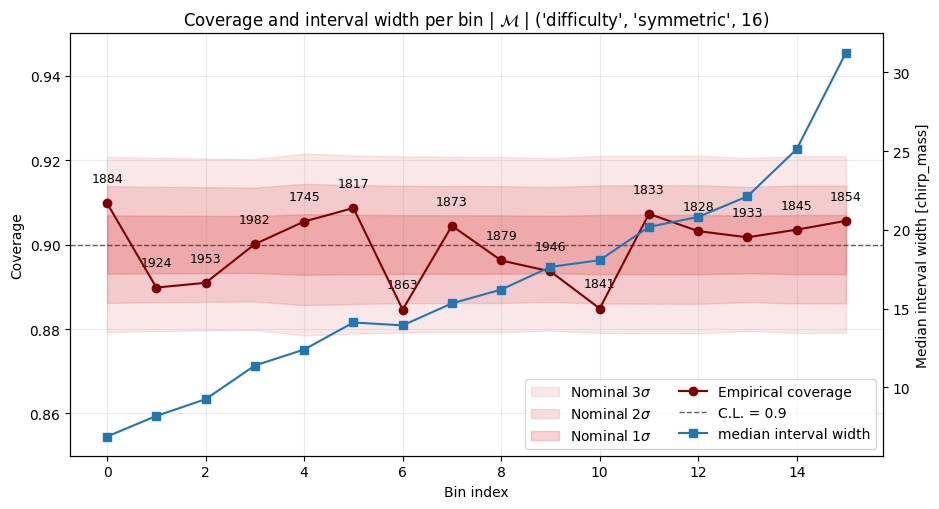

In [49]:
key = ("difficulty", "symmetric", 16)

width_per_bin_phys = plot_coverage_and_width_per_bin(
    all_results=all_results,
    key=key,
    label_idx=0,
    label_names=label_names,
    plot_labels=plot_labels,
    confidence_level=0.90,
    width_stat="median",
    width_space="phys",
    y_std=y_std,
)
    

## Final candidate configuration

In [40]:
best_by_label = (
    ranking_df
    .groupby("label", group_keys=False)
    .head(1)
)

best_by_label[
    [
        "label",
        "taxonomy_mode",
        "interval_mode",
        "n_bins",
        "global_coverage",
        "global_median_width_std",
        "global_median_width_phys",
        "bad_bin_fraction",
        "max_undercoverage_gap",
        "global_tail_miss_imbalance",
    ]
]

,label,taxonomy_mode,interval_mode,n_bins,global_coverage,global_median_width_std,global_median_width_phys,bad_bin_fraction,max_undercoverage_gap,global_tail_miss_imbalance
68,chi_eff,difficulty,symmetric,32,0.899833,1.378087,0.607537,0.09375,0.049254,0.000167
48,chirp_mass,difficulty,symmetric,4,0.900700,0.844578,13.922626,0.00000,0.003965,0.003967
49,total_mass,difficulty,symmetric,4,0.901467,0.799856,27.715133,0.00000,0.002259,0.027200


Best configuration for label: chi_eff
key = ('difficulty', 'symmetric', 32)
Configuration: ('difficulty', 'symmetric', 32)
Label: chi_eff

Counts per bin:
[ 965  941  931  977  930  938  960  985  964  896  966  869  864  887
  877  984  984  928  881  852  972  956  936 1020  930  957  937  881
  914 1023  953  942]

Coverage per bin:
[0.922 0.904 0.909 0.904 0.887 0.851 0.883 0.912 0.898 0.908 0.891 0.891
 0.9   0.903 0.902 0.913 0.894 0.895 0.919 0.893 0.928 0.919 0.865 0.896
 0.892 0.9   0.908 0.909 0.864 0.913 0.909 0.906]

Covered count per bin:
[890 851 846 883 825 798 848 898 866 814 861 774 778 801 791 898 880 831
 810 761 902 879 810 914 830 861 851 801 790 934 866 853]

Bin undercoverage p-values:
[9.925e-01 6.875e-01 8.259e-01 6.687e-01 1.058e-01 0.000e+00 5.010e-02
 9.005e-01 4.474e-01 8.158e-01 1.973e-01 1.939e-01 5.347e-01 6.350e-01
 5.923e-01 9.169e-01 2.905e-01 3.383e-01 9.786e-01 2.693e-01 9.990e-01
 9.826e-01 4.000e-04 3.530e-01 2.365e-01 5.029e-01 8.133e-01 8.327e-0

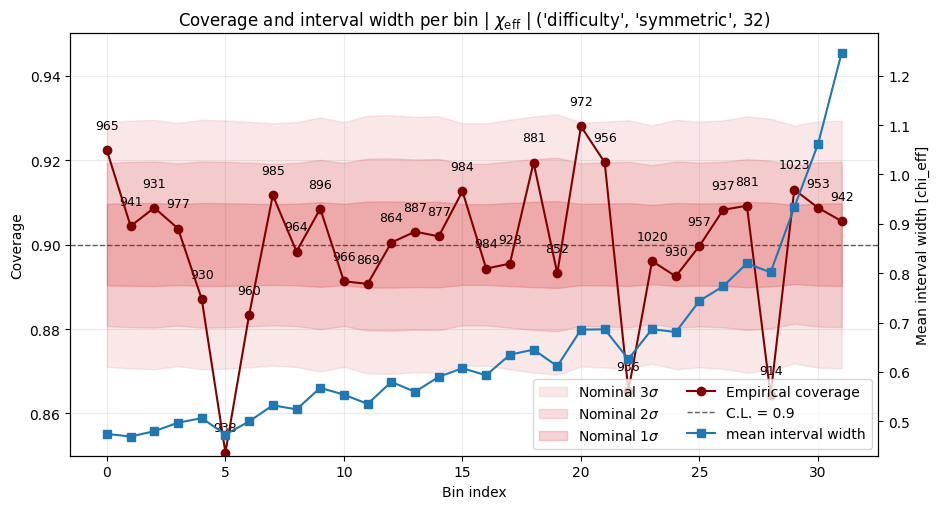

Best configuration for label: chirp_mass
key = ('difficulty', 'symmetric', 4)
Configuration: ('difficulty', 'symmetric', 4)
Label: chirp_mass

Counts per bin:
[7743 7298 7499 7460]

Coverage per bin:
[0.896 0.899 0.899 0.908]

Covered count per bin:
[6938 6563 6743 6777]

Bin undercoverage p-values:
[0.1266 0.4253 0.4128 0.9934]

Lower miss rate per bin:
[0.051 0.046 0.048 0.045]

Upper miss rate per bin:
[0.053 0.054 0.052 0.047]

Interval offsets per bin:
[[-0.2747  0.2747]
 [-0.4223  0.4223]
 [-0.5522  0.5522]
 [-0.7777  0.7777]]

Calibrator bin counts:
[7500 7500 7500 7500]

Quantile indices:
[[6750 6750]
 [6750 6750]
 [6750 6750]
 [6750 6750]]


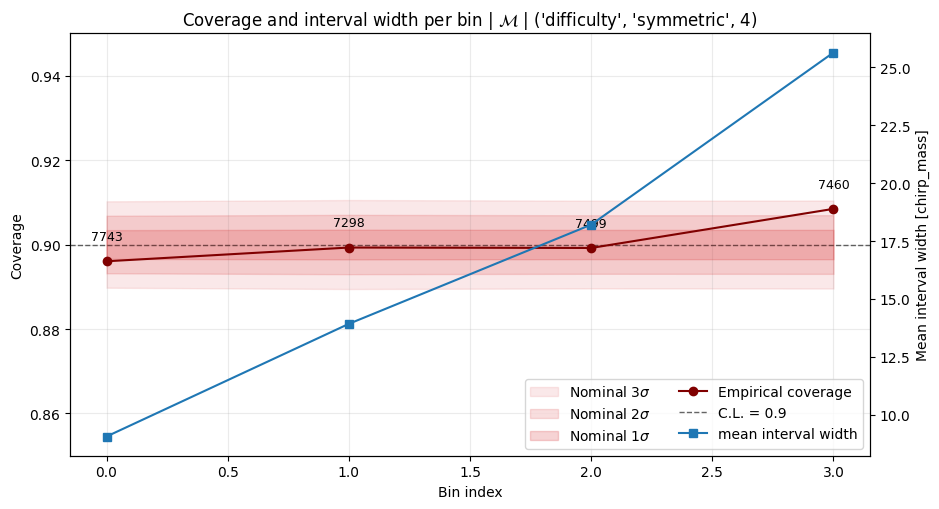

Best configuration for label: total_mass
key = ('difficulty', 'symmetric', 4)
Configuration: ('difficulty', 'symmetric', 4)
Label: total_mass

Counts per bin:
[7536 7481 7480 7503]

Coverage per bin:
[0.9   0.898 0.902 0.906]

Covered count per bin:
[6782 6716 6748 6798]

Bin undercoverage p-values:
[0.4995 0.2627 0.7366 0.9619]

Lower miss rate per bin:
[0.034 0.039 0.035 0.035]

Upper miss rate per bin:
[0.066 0.063 0.063 0.059]

Interval offsets per bin:
[[-0.319   0.319 ]
 [-0.3999  0.3999]
 [-0.4802  0.4802]
 [-0.6503  0.6503]]

Calibrator bin counts:
[7500 7500 7500 7500]

Quantile indices:
[[6750 6750]
 [6750 6750]
 [6750 6750]
 [6750 6750]]


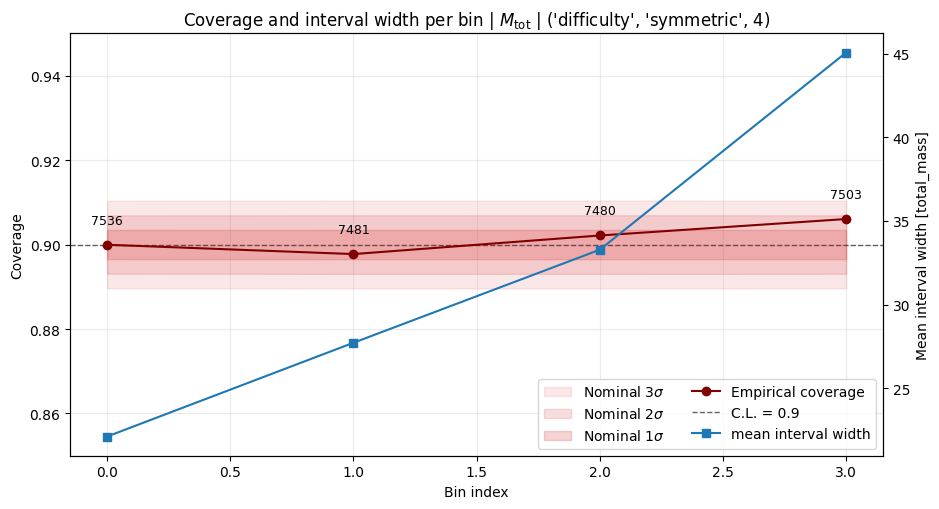

In [41]:
for row in best_by_label.itertuples():
    key = (row.taxonomy_mode, row.interval_mode, row.n_bins)
    label_idx = int(row.label_index)
    label = label_names[label_idx]

    print("=" * 80)
    print(f"Best configuration for label: {label}")
    print(f"key = {key}")
    print("=" * 80)

    inspect_configuration(
        all_results=all_results,
        key=key,
        label_idx=label_idx,
        label_names=label_names,
    )

    width_per_bin_phys = plot_coverage_and_width_per_bin(
        all_results=all_results,
        key=key,
        label_idx=label_idx,
        label_names=label_names,
        plot_labels=plot_labels,
        confidence_level=0.90,
        width_stat="mean",
        width_space="phys",
        y_std=y_std,
    )

In [42]:
key = (row.taxonomy_mode, row.interval_mode, row.n_bins)
label_idx = int(row.label_index)

result = all_results[key]
metrics = result.metrics

print("key:", key)
print("label:", label_names[label_idx])

print("coverage_per_bin:")
print(metrics["coverage_per_bin"][:, label_idx])

print("counts_per_bin:")
print(metrics["counts_per_bin"][:, label_idx])

print("mean_width_per_bin:")
print(metrics["mean_width_per_bin"][:, label_idx])

print("median_width_per_bin:")
print(metrics["median_width_per_bin"][:, label_idx])

key: ('difficulty', 'symmetric', 4)
label: total_mass
coverage_per_bin:
[0.89994692 0.89774094 0.90213904 0.90603758]
counts_per_bin:
[7536 7481 7480 7503]
mean_width_per_bin:
[0.63809919 0.79985571 0.96035844 1.30052093]
median_width_per_bin:
[0.63809919 0.79985571 0.96035844 1.30052093]


In [43]:
mean_w = metrics["mean_width_per_bin"][:, label_idx]
median_w = metrics["median_width_per_bin"][:, label_idx]

print("mean == median per bin?")
print(np.allclose(mean_w, median_w, equal_nan=True))

print("width changes across bins?")
print(np.nanmin(mean_w), np.nanmax(mean_w))
print("unique rounded widths:")
print(np.unique(np.round(mean_w, 6)))

mean == median per bin?
True
width changes across bins?
0.638099193572998 1.3005209267139435
unique rounded widths:
[0.638099 0.799856 0.960358 1.300521]
